### Importing

In [29]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Input , Dense , Dropout , Conv2D , MaxPooling2D , Flatten
from keras.utils import to_categorical
from keras.datasets import mnist
from sklearn.metrics import classification_report

### Loading Data

In [4]:
(X_train , y_train) , (X_test , y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


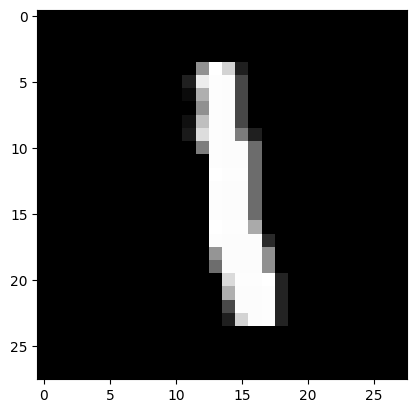

In [7]:
plt.imshow(X_train[6] , cmap = "gray")
plt.show()

### Reshaping
### Tensorflow can handle format : (batch , height , width , channel)

In [8]:
X_train = X_train.reshape(-1 , 28 , 28 , 1)
X_test = X_test.reshape(-1 , 28 , 28 , 1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### Min Max Scaler

In [9]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train = X_train / 255.0
X_test = X_test / 255.0

### One Hot Encoding

In [10]:
y_train = to_categorical(y_train , num_classes = 10)
y_test = to_categorical(y_test , num_classes = 10)

print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


### Adding Layers

In [11]:
model = Sequential()

model.add(Input(shape = (28 , 28 , 1)))
model.add(Conv2D(filters = 32 , kernel_size = (3 , 3) , activation = "relu"))
model.add(MaxPooling2D(pool_size = (2 , 2)))

model.add(Conv2D(filters = 32 , kernel_size = (3 , 3) , activation = "relu"))
model.add(MaxPooling2D(pool_size = (2 , 2)))
model.add(Flatten())

model.add(Dense(units = 100 , activation = "relu"))
model.add(Dropout(0.2))
model.add(Dense(units = 10 , activation = "softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        80,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,678 (354.21 KB)

 Trainable params: 90,678 (354.21 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling Model

In [12]:
model.compile(loss = "categorical_crossentropy" , optimizer = "adam" , metrics = ["accuracy"])

### Model Training

In [14]:
history = model.fit(X_train , y_train , epochs = 10 , validation_data = (X_test , y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9961 - loss: 0.0122 - val_accuracy: 0.9914 - val_loss: 0.0342
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accuracy: 0.9922 - val_loss: 0.0307
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9968 - loss: 0.0101 - val_accuracy: 0.9918 - val_loss: 0.0289
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9972 - loss: 0.0088 - val_accuracy: 0.9912 - val_loss: 0.0337
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9967 - loss: 0.0098 - val_accuracy: 0.9928 - val_loss: 0.0333
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9975 - loss: 0.0079 - val_accuracy: 0.9918 - val_loss: 0.0378
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9971 - loss: 0.0086 - val_accuracy: 0.9913 - val_loss: 0.0421
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9977 - loss: 0.0071 -

### History Visualization

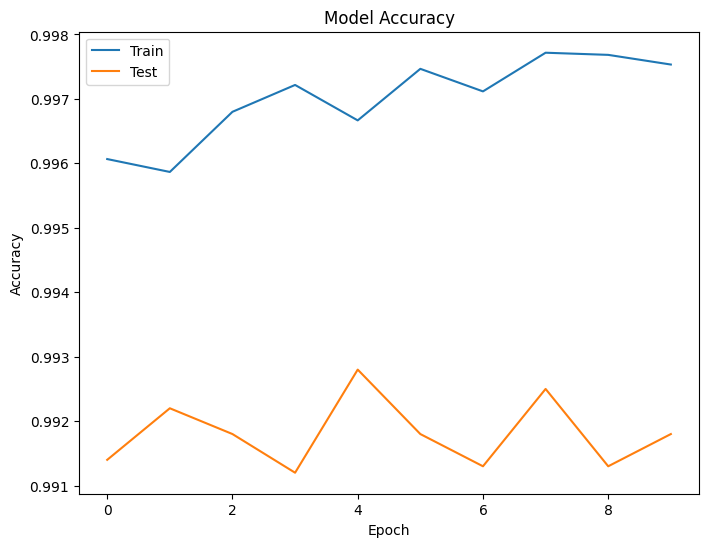

In [22]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train" , "Test"])
plt.show()

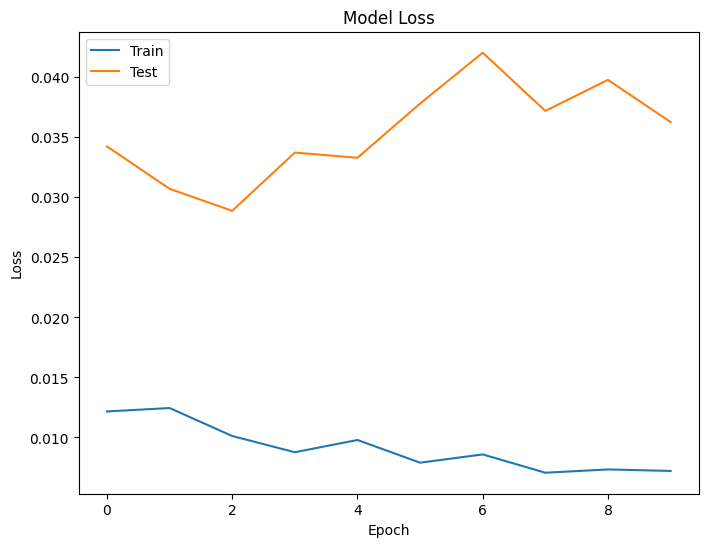

In [23]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train" , "Test"])
plt.show()

### Evaluation

In [24]:
result = model.evaluate(X_test , y_test , verbose = 0)
print(f"Accuracy : {result[1]} , Loss : {result[0]}")

Accuracy : 0.9918000102043152 , Loss : 0.03627542406320572


In [28]:
print(classification_report(np.argmax(y_test , axis = 1) , np.argmax(model.predict(X_test) , axis = 1)))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Prediction

Prediction: 5


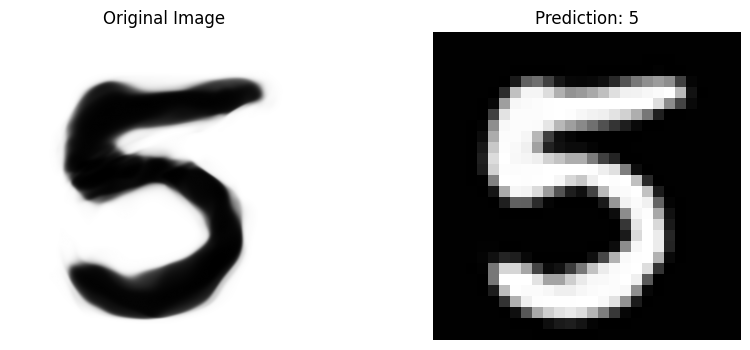

In [34]:
image_path = "/content/mnist_dream_10.png"

original_img = Image.open(image_path)

img = original_img.convert("L")

img = img.resize((28 , 28))

img_array = np.array(img)

if img_array.mean() > 127:
    img_array = 255 - img_array

img_array = img_array.astype("float32")
img_array = img_array / 255.0

input_image = img_array.reshape(1 , 28 , 28 , 1)

prediction = model.predict(input_image , verbose=0)

predicted_class = np.argmax(prediction)
print(f"Prediction: {predicted_class}")

plt.figure(figsize = (10 , 4))
plt.subplot(1 , 2 , 1)
plt.imshow(original_img , cmap = "gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1 , 2 , 2)
plt.imshow(img_array , cmap = "gray")
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()